# Online Retail Dataset — Python Visualizations

**Goal:** Build a few sharper, more custom visualizations using matplotlib/seaborn that go beyond what's easy to do in Excel — trend + growth rate, distribution analysis, and a day/hour activity heatmap.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/online_retail_cleaned.csv', parse_dates=['InvoiceDate'])
print('Shape:', df.shape)
df.head()

Shape: (524878, 15)


C:\Users\navya\AppData\Local\Temp\ipykernel_13424\1078703323.py:8: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/online_retail_cleaned.csv', parse_dates=['InvoiceDate'])


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,HasCustomerID,Revenue,InvoiceYear,InvoiceMonth,InvoiceYearMonth,InvoiceDay,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,True,15.30,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,True,22.00,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,True,20.34,2010,12,2010-12,Wednesday,8


## Chart 1: Monthly Revenue Trend with Month-over-Month Growth Rate

This goes beyond a simple line chart — we add a secondary axis showing % growth, which highlights momentum shifts that the raw revenue numbers alone don't show clearly.

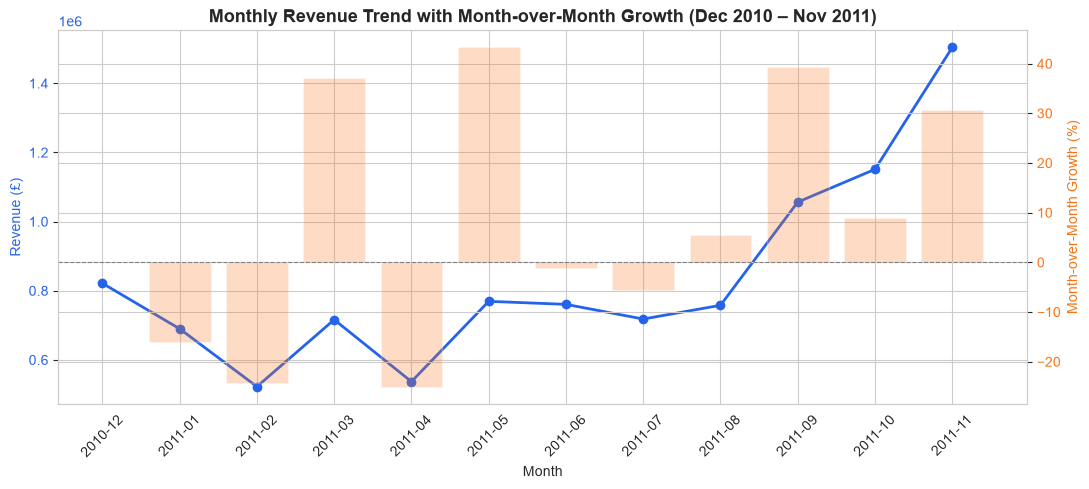

In [6]:
monthly = df.groupby('InvoiceYearMonth')['Revenue'].sum().reset_index()
monthly = monthly.sort_values('InvoiceYearMonth')
monthly['MoM_Growth_%'] = monthly['Revenue'].pct_change() * 100

# Drop the last month if it's a partial month (data ends Dec 9, 2011)
monthly_full = monthly.iloc[:-1].copy()

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(monthly_full['InvoiceYearMonth'], monthly_full['Revenue'], color='#2563eb', marker='o', linewidth=2, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (£)', color='#2563eb')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.bar(monthly_full['InvoiceYearMonth'], monthly_full['MoM_Growth_%'], alpha=0.25, color='#f97316', label='MoM Growth %')
ax2.set_ylabel('Month-over-Month Growth (%)', color='#f97316')
ax2.tick_params(axis='y', labelcolor='#f97316')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.title('Monthly Revenue Trend with Month-over-Month Growth (Dec 2010 – Nov 2011)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('../data/chart_monthly_revenue_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Customer Order Frequency Distribution

How many orders does a typical customer place? This histogram shows whether the business relies mostly on one-time buyers or has a healthy base of repeat customers — important for retention strategy.

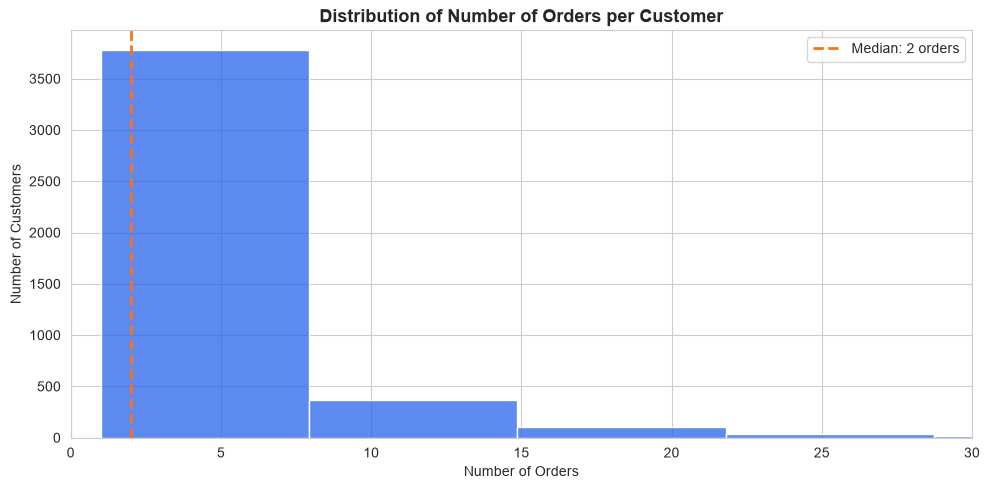

% of customers who ordered only once: 34.4 %


In [7]:
customer_orders = df[df['HasCustomerID'] == True].groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
customer_orders.columns = ['CustomerID', 'NumOrders']

plt.figure(figsize=(10, 5))
sns.histplot(customer_orders['NumOrders'], bins=30, color='#2563eb')
plt.axvline(customer_orders['NumOrders'].median(), color='#f97316', linestyle='--', linewidth=2, 
            label=f"Median: {customer_orders['NumOrders'].median():.0f} orders")
plt.xlim(0, customer_orders['NumOrders'].quantile(0.99))  # cut off extreme outliers for readability
plt.title('Distribution of Number of Orders per Customer', fontsize=13, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.savefig('../data/chart_customer_order_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('% of customers who ordered only once:', 
      round((customer_orders['NumOrders'] == 1).sum() / len(customer_orders) * 100, 1), '%')

## Chart 3: Order Activity Heatmap (Day of Week x Hour)

This shows exactly when customers are most active — useful for things like timing email campaigns or flash sales. A heatmap like this isn't easy to build cleanly in Excel.

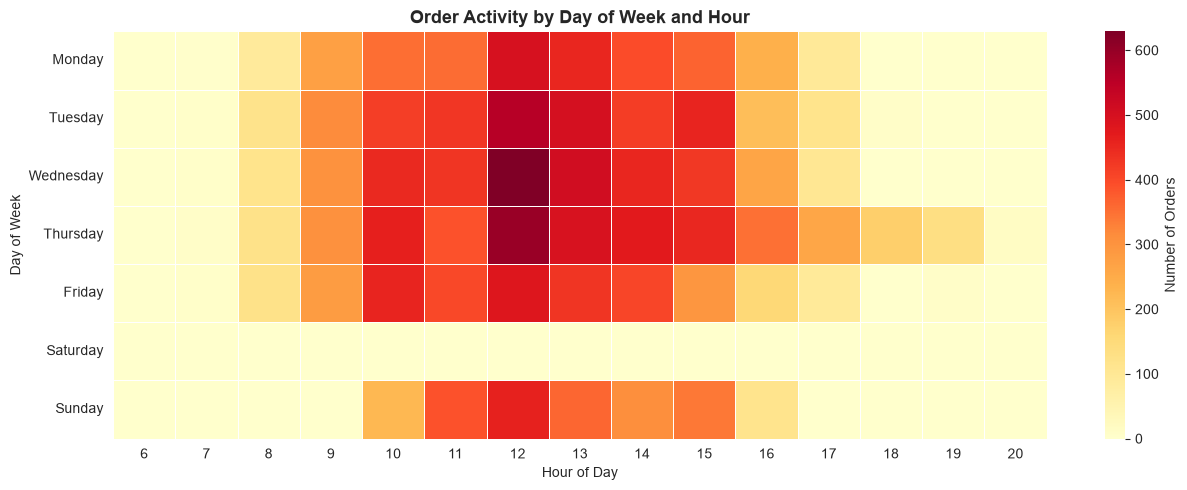

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['InvoiceDay', 'InvoiceHour'])['InvoiceNo'].nunique().reset_index()
heatmap_pivot = heatmap_data.pivot(index='InvoiceDay', columns='InvoiceHour', values='InvoiceNo')
heatmap_pivot = heatmap_pivot.reindex(day_order)
heatmap_pivot = heatmap_pivot.fillna(0)

plt.figure(figsize=(13, 5))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Number of Orders'})
plt.title('Order Activity by Day of Week and Hour', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../data/chart_activity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of findings from these charts

- **Revenue trend:** Revenue grew steadily through 2011, with a sharp acceleration from August (£758K) to November (£1.5M) — a 98% increase over four months, likely driven by pre-holiday shopping. November was the peak month.

- **Customer behavior:** 34.4% of customers placed only one order, while the remaining ~66% returned at least once — suggesting a meaningful repeat-customer base, but also room to improve first-purchase retention.

- **Activity timing:** Order activity is concentrated on weekday late mornings to early afternoons (roughly 10am-3pm, Tue-Fri), with Saturday being the quietest day by far. This suggests promotional emails or flash sales would perform best if timed around weekday midday rather than weekends.

